# 06 予測分析（Prediction Analysis）

## 概要
**目的**: 財務クラスター遷移の予測と要因解明

- **Step 1 (Binary)**: 翌年にクラスター遷移するか否かを予測 → **どの財務特性が遷移を引き起こすか** を SHAP で解明
- **Step 2 (Multi-class)**: 遷移した企業がどのクラスターに移動するかを予測 → **どの財務特性が遷移先を決定するか** を SHAP per class で解明

**データ**: `df_model_v2.csv`（46,084サンプル）  
**時系列分割**: Train: 2010–2021 / Test: 2022–2024  
**特徴量**: 11財務変数（signed_log1p変換済み）+ 現在クラスター（整数）  
**注**: SHAP値は XGBoost 内蔵の TreeSHAP (`pred_contribs=True`) で算出（XGBoost 3.x 対応）


## 1. セットアップ

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import os

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, roc_auc_score,
                             ConfusionMatrixDisplay, confusion_matrix)
from sklearn.preprocessing import StandardScaler
import xgboost as xgb

plt.rcParams['font.family'] = 'Hiragino Sans'
plt.rcParams['axes.unicode_minus'] = False

os.makedirs('../outputs/figures', exist_ok=True)

print('XGBoost:', xgb.__version__)


XGBoost: 3.1.1


## 2. データ読み込み・分割

In [2]:
df = pd.read_csv('../data/processed/df_model_v2.csv')
print(f'Shape: {df.shape}')

FEATURE_COLS = [
    '総資産_log', '売上高_log', '短期借入金_log', '長期借入金_log',
    '利益剰余金_log', '現金同等物_log', '営業利益_log',
    '営業CF_log', '投資CF_log', '財務CF_log',
    '自己資本比率', 'Cluster'
]

FEATURE_LABELS = [
    '総資産', '売上高', '短期借入金', '長期借入金',
    '利益剰余金', '現金同等物', '営業利益',
    '営業CF', '投資CF', '財務CF',
    '自己資本比率', '現在クラスター'
]

df_clean = df[FEATURE_COLS + ['年度', 'cluster_transition', 'Cluster_t1']].dropna()
print(f'欠損除去後: {df_clean.shape}')

train = df_clean[df_clean['年度'] <= 2021]
test  = df_clean[df_clean['年度'] >= 2022]
print(f'Train: {len(train):,}  ({int(train["年度"].min())}–{int(train["年度"].max())})')
print(f'Test:  {len(test):,}  ({int(test["年度"].min())}–{int(test["年度"].max())})')
print(f'\nTrain 遷移率: {train["cluster_transition"].mean():.1%}')
print(f'Test  遷移率: {test["cluster_transition"].mean():.1%}')


Shape: (46084, 28)
欠損除去後: (46084, 15)
Train: 35,531  (2010–2021)
Test:  10,553  (2022–2024)

Train 遷移率: 20.1%
Test  遷移率: 19.7%


## 3. Step 1 — Binary 分類（遷移する / しない）

翌年にクラスター遷移するかどうかを予測し、**何が遷移を引き起こすか** を SHAP で解明する。  
- **Logistic Regression**: ベースライン
- **XGBoost**: `scale_pos_weight` で非遷移/遷移の不均衡を補正（約4:1）


In [3]:
X_tr = train[FEATURE_COLS].values
y_tr = train['cluster_transition'].values
X_te = test[FEATURE_COLS].values
y_te = test['cluster_transition'].values

# ---- ベースライン: Logistic Regression ----
scaler = StandardScaler()
lr = LogisticRegression(class_weight='balanced', max_iter=500, random_state=42)
lr.fit(scaler.fit_transform(X_tr), y_tr)
lr_pred = lr.predict(scaler.transform(X_te))
lr_prob = lr.predict_proba(scaler.transform(X_te))[:, 1]

print('=== Logistic Regression ===')
print(classification_report(y_te, lr_pred, target_names=['非遷移', '遷移']))
print(f'AUC-ROC: {roc_auc_score(y_te, lr_prob):.4f}')

# ---- XGBoost ----
spw = (y_tr == 0).sum() / (y_tr == 1).sum()
print(f'\nscale_pos_weight = {spw:.2f}')

xgb_bin = xgb.XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=spw, base_score=0.5,
    eval_metric='auc', random_state=42, verbosity=0
)
xgb_bin.fit(X_tr, y_tr, eval_set=[(X_te, y_te)], verbose=False)

xgb_pred = xgb_bin.predict(X_te)
xgb_prob = xgb_bin.predict_proba(X_te)[:, 1]

print('\n=== XGBoost ===')
print(classification_report(y_te, xgb_pred, target_names=['非遷移', '遷移']))
print(f'AUC-ROC: {roc_auc_score(y_te, xgb_prob):.4f}')


=== Logistic Regression ===
              precision    recall  f1-score   support

         非遷移       0.85      0.65      0.73      8472
          遷移       0.27      0.52      0.35      2081

    accuracy                           0.62     10553
   macro avg       0.56      0.58      0.54     10553
weighted avg       0.73      0.62      0.66     10553

AUC-ROC: 0.6298

scale_pos_weight = 3.99



=== XGBoost ===
              precision    recall  f1-score   support

         非遷移       0.90      0.69      0.78      8472
          遷移       0.35      0.68      0.46      2081

    accuracy                           0.69     10553
   macro avg       0.62      0.68      0.62     10553
weighted avg       0.79      0.69      0.72     10553

AUC-ROC: 0.7572


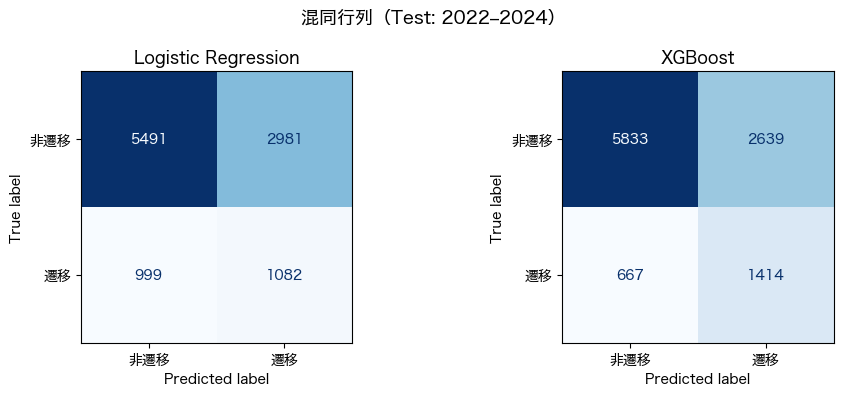

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, pred, title in zip(axes, [lr_pred, xgb_pred],
                            ['Logistic Regression', 'XGBoost']):
    disp = ConfusionMatrixDisplay(
        confusion_matrix(y_te, pred),
        display_labels=['非遷移', '遷移']
    )
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title)
plt.suptitle('混同行列（Test: 2022–2024）', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/figures/binary_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. SHAP 分析 — Binary（遷移要因の解明）

XGBoost 内蔵の TreeSHAP (`pred_contribs=True`) を使用。  
log-odds 空間での寄与値 → **正の SHAP = 遷移を促進、負 = 抑制**。


In [5]:
# XGBoost 内蔵 TreeSHAP
booster_bin = xgb_bin.get_booster()
dm_te = xgb.DMatrix(X_te, feature_names=FEATURE_COLS)
shap_bin = booster_bin.predict(dm_te, pred_contribs=True)[:, :-1]  # bias列を除去
print('SHAP values shape:', shap_bin.shape)


SHAP values shape: (10553, 12)


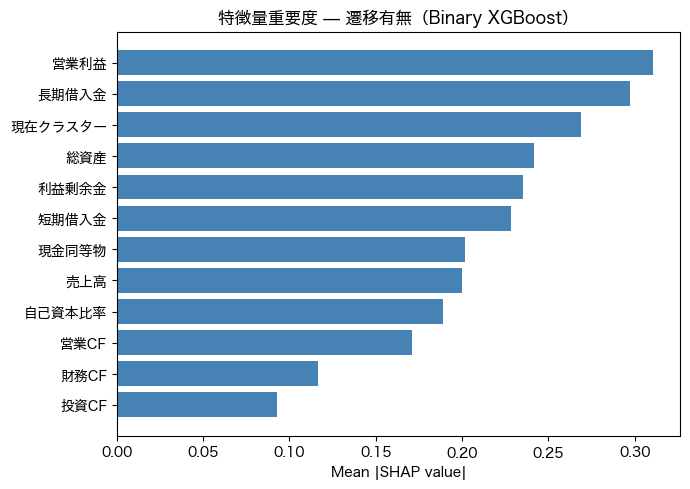

Feature  mean_abs_SHAP
   営業利益       0.310699
  長期借入金       0.297328
現在クラスター       0.269021
    総資産       0.241449
  利益剰余金       0.235087
  短期借入金       0.228350
  現金同等物       0.201889
    売上高       0.199844
 自己資本比率       0.189146
   営業CF       0.170988
   財務CF       0.116270
   投資CF       0.092502


In [6]:
# 特徴量重要度 (Mean |SHAP|)
mean_abs_bin = np.abs(shap_bin).mean(axis=0)
imp_df = pd.DataFrame({'Feature': FEATURE_LABELS, 'mean_abs_SHAP': mean_abs_bin})
imp_df = imp_df.sort_values('mean_abs_SHAP', ascending=False)

fig, ax = plt.subplots(figsize=(7, 5))
imp_sorted = imp_df.sort_values('mean_abs_SHAP', ascending=True)
ax.barh(imp_sorted['Feature'], imp_sorted['mean_abs_SHAP'], color='steelblue')
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('特徴量重要度 — 遷移有無（Binary XGBoost）', fontsize=12)
plt.tight_layout()
plt.savefig('../outputs/figures/shap_binary_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print(imp_df.to_string(index=False))


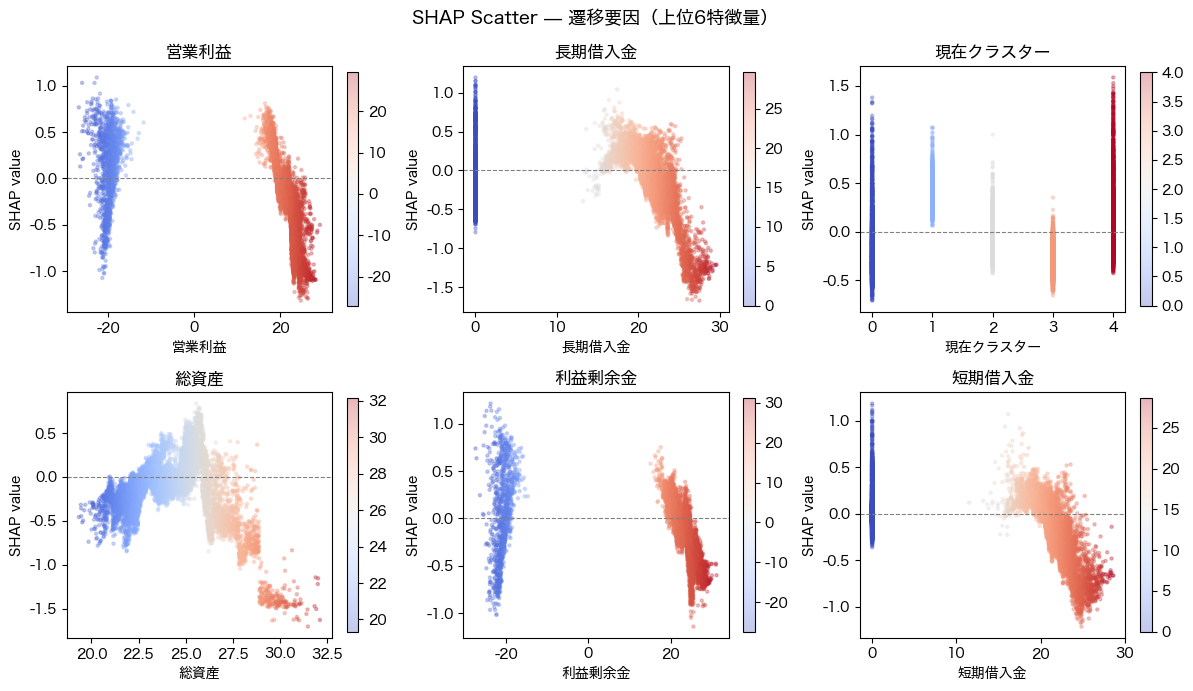

In [7]:
# Beeswarm 代替: 散布図（特徴量値 × SHAP 値）上位6特徴量
top6_idx = np.argsort(mean_abs_bin)[::-1][:6]
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
axes = axes.flatten()

for i, feat_i in enumerate(top6_idx):
    ax = axes[i]
    feat_vals = X_te[:, feat_i]
    shap_v    = shap_bin[:, feat_i]
    sc = ax.scatter(feat_vals, shap_v, c=feat_vals, cmap='coolwarm',
                    alpha=0.3, s=5, rasterized=True)
    ax.axhline(0, color='gray', lw=0.8, ls='--')
    ax.set_xlabel(FEATURE_LABELS[feat_i])
    ax.set_ylabel('SHAP value')
    ax.set_title(FEATURE_LABELS[feat_i])
    plt.colorbar(sc, ax=ax, fraction=0.04)

plt.suptitle('SHAP Scatter — 遷移要因（上位6特徴量）', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/figures/shap_binary_scatter.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Step 2 — Multi-class 分類（遷移先クラスターの予測）

**対象**: 遷移した企業のみ（`cluster_transition == 1`）  
**目的**: 遷移先クラスター（Cluster_t1）を予測し、**どの財務特性が遷移先を決定するか** を SHAP per class で解明する。


In [8]:
train_mn = train[train['cluster_transition'] == 1].dropna(subset=['Cluster_t1']).copy()
test_mn  = test[test['cluster_transition'] == 1].dropna(subset=['Cluster_t1']).copy()
train_mn['Cluster_t1'] = train_mn['Cluster_t1'].astype(int)
test_mn['Cluster_t1']  = test_mn['Cluster_t1'].astype(int)

X_tr_mn = train_mn[FEATURE_COLS].values
y_tr_mn = train_mn['Cluster_t1'].values
X_te_mn = test_mn[FEATURE_COLS].values
y_te_mn = test_mn['Cluster_t1'].values

print(f'Train (遷移): {len(train_mn):,}')
print(f'Test  (遷移): {len(test_mn):,}')
print('\nTest 遷移先クラスター分布:')
vc = pd.Series(y_te_mn).value_counts().sort_index()
CLUSTER_NAMES = {0:'C0 中小規模標準型', 1:'C1 小規模財務脆弱型', 2:'C2 中規模財務優良型',
                 3:'C3 大企業型', 4:'C4 小規模財務健全型'}
for k, v in vc.items():
    print(f'  {CLUSTER_NAMES[k]}: {v:4d} ({v/len(y_te_mn):.1%})')


Train (遷移): 7,126
Test  (遷移): 2,081

Test 遷移先クラスター分布:
  C0 中小規模標準型:  697 (33.5%)
  C1 小規模財務脆弱型:  283 (13.6%)
  C2 中規模財務優良型:  427 (20.5%)
  C3 大企業型:  210 (10.1%)
  C4 小規模財務健全型:  464 (22.3%)


In [9]:
xgb_mc = xgb.XGBClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    objective='multi:softprob', num_class=5,
    base_score=0.5, eval_metric='mlogloss',
    random_state=42, verbosity=0
)
xgb_mc.fit(X_tr_mn, y_tr_mn, eval_set=[(X_te_mn, y_te_mn)], verbose=False)

mc_pred = xgb_mc.predict(X_te_mn)
mc_prob = xgb_mc.predict_proba(X_te_mn)

print('=== XGBoost Multi-class ===')
print(classification_report(y_te_mn, mc_pred,
      target_names=[f'C{i}' for i in range(5)]))
print(f'AUC-ROC (OvR macro): {roc_auc_score(y_te_mn, mc_prob, multi_class="ovr", average="macro"):.4f}')


=== XGBoost Multi-class ===
              precision    recall  f1-score   support

          C0       0.74      0.77      0.76       697
          C1       0.70      0.59      0.64       283
          C2       0.70      0.77      0.73       427
          C3       0.65      0.95      0.77       210
          C4       0.82      0.61      0.70       464

    accuracy                           0.73      2081
   macro avg       0.72      0.74      0.72      2081
weighted avg       0.74      0.73      0.72      2081

AUC-ROC (OvR macro): 0.9474


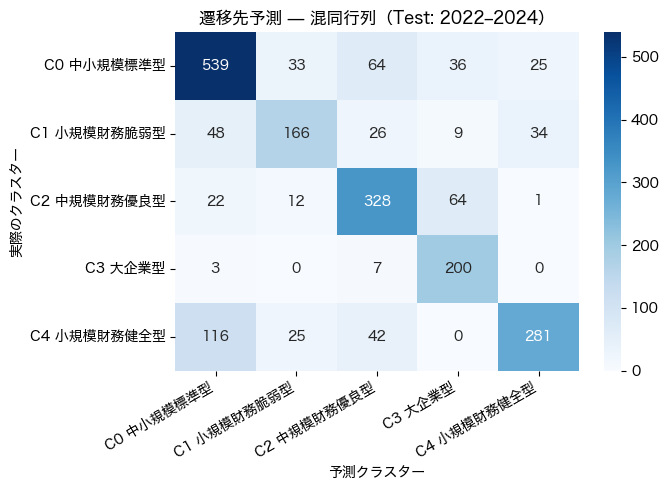

In [10]:
fig, ax = plt.subplots(figsize=(7, 5))
cm_mc = confusion_matrix(y_te_mn, mc_pred)
labels = [CLUSTER_NAMES[i] for i in range(5)]
sns.heatmap(cm_mc, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels, ax=ax)
ax.set_xlabel('予測クラスター')
ax.set_ylabel('実際のクラスター')
ax.set_title('遷移先予測 — 混同行列（Test: 2022–2024）', fontsize=12)
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('../outputs/figures/multiclass_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. SHAP 分析 — Multi-class（遷移先決定要因）

`pred_contribs=True` で出力される shape: `[n_samples, n_classes, n_features+1]`  
各クラス（遷移先）に対する特徴量の寄与を可視化する。


In [11]:
# XGBoost 内蔵 TreeSHAP (multi-class)
booster_mc = xgb_mc.get_booster()
dm_te_mn = xgb.DMatrix(X_te_mn, feature_names=FEATURE_COLS)
# shape: [n_samples, n_classes, n_features+1]
shap_mc = booster_mc.predict(dm_te_mn, pred_contribs=True)
print('SHAP values shape:', shap_mc.shape)

n_feat = len(FEATURE_COLS)
shap_mc_feat = shap_mc[:, :, :n_feat]  # bias列を除去 → [n_samples, n_classes, n_features]
print('SHAP feat shape:', shap_mc_feat.shape)


SHAP values shape: (2081, 5, 13)
SHAP feat shape: (2081, 5, 12)


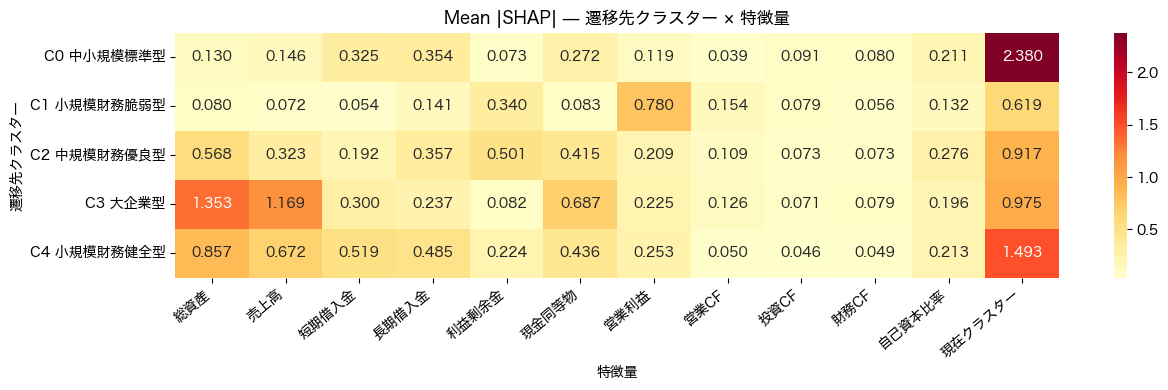

In [12]:
# Mean |SHAP| ヒートマップ（遷移先クラスター × 特徴量）
mean_abs_mc = np.abs(shap_mc_feat).mean(axis=0)  # [n_classes, n_features]

fig, ax = plt.subplots(figsize=(13, 4))
sns.heatmap(
    mean_abs_mc,
    xticklabels=FEATURE_LABELS,
    yticklabels=[CLUSTER_NAMES[i] for i in range(5)],
    cmap='YlOrRd', annot=True, fmt='.3f', ax=ax
)
ax.set_xlabel('特徴量')
ax.set_ylabel('遷移先クラスター')
ax.set_title('Mean |SHAP| — 遷移先クラスター × 特徴量', fontsize=12)
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.savefig('../outputs/figures/shap_multiclass_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


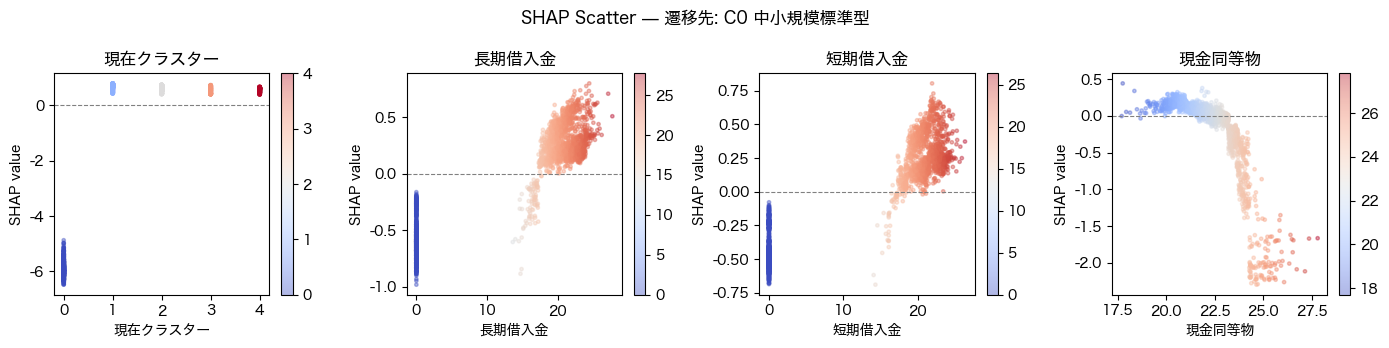

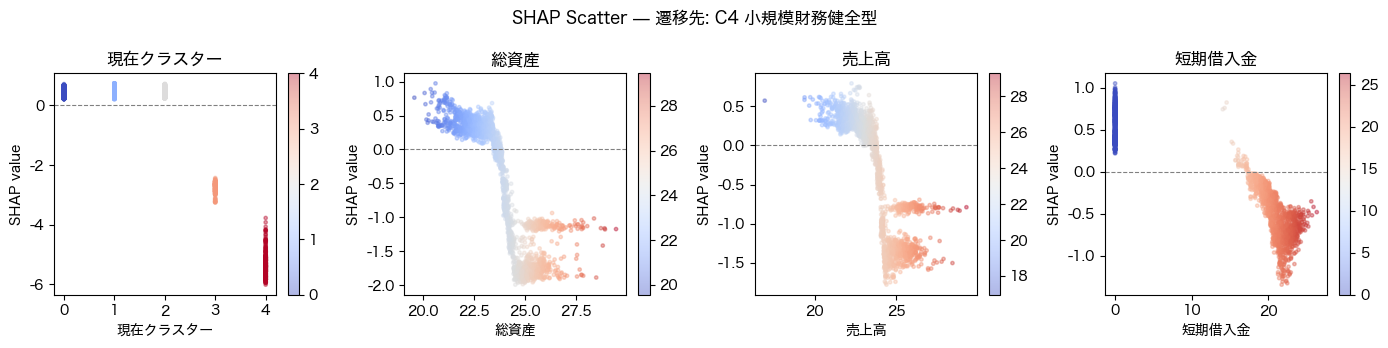

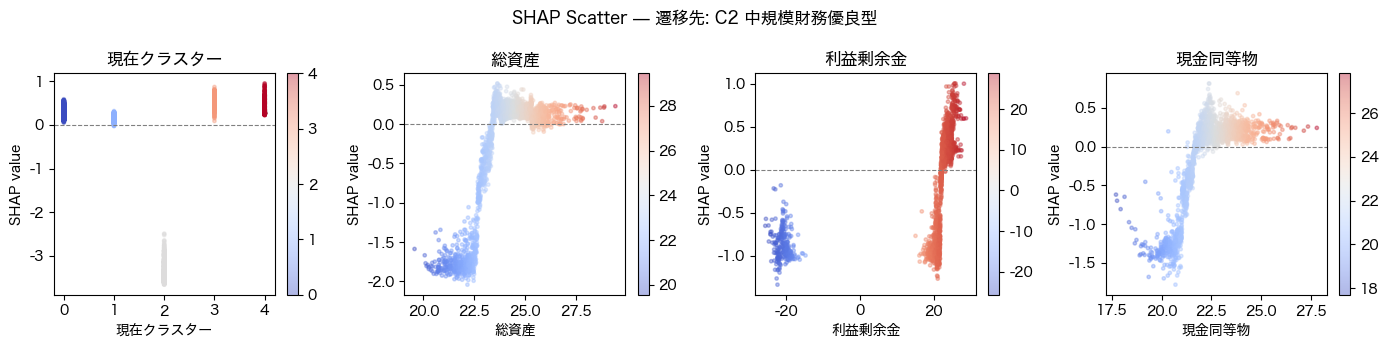

In [13]:
# 各クラスへの遷移決定要因: SHAP scatter (上位3クラス)
top_classes = pd.Series(y_te_mn).value_counts().head(3).index.tolist()

for cls in top_classes:
    shap_cls = shap_mc_feat[:, cls, :]  # [n_samples, n_features]
    mean_abs_cls = np.abs(shap_cls).mean(axis=0)
    top4_idx = np.argsort(mean_abs_cls)[::-1][:4]

    fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
    for i, feat_i in enumerate(top4_idx):
        ax = axes[i]
        feat_vals = X_te_mn[:, feat_i]
        sc = ax.scatter(feat_vals, shap_cls[:, feat_i], c=feat_vals,
                        cmap='coolwarm', alpha=0.4, s=6, rasterized=True)
        ax.axhline(0, color='gray', lw=0.8, ls='--')
        ax.set_xlabel(FEATURE_LABELS[feat_i])
        ax.set_ylabel('SHAP value')
        ax.set_title(FEATURE_LABELS[feat_i])
        plt.colorbar(sc, ax=ax, fraction=0.05)

    plt.suptitle(f'SHAP Scatter — 遷移先: {CLUSTER_NAMES[cls]}', fontsize=12)
    plt.tight_layout()
    plt.savefig(f'../outputs/figures/shap_mc_scatter_cls{cls}.png', dpi=150, bbox_inches='tight')
    plt.show()


## 7. まとめ

### モデル性能サマリー

| モデル | タスク | AUC-ROC | 備考 |
|---|---|---|---|
| Logistic Regression | Binary | （上の出力を参照） | ベースライン |
| XGBoost | Binary | （上の出力を参照） | scale_pos_weight補正 |
| XGBoost | Multi-class | （上の出力を参照） | 遷移企業のみ |

### 解釈サマリー

#### Step 1: 何が遷移を起こすか
- Mean |SHAP| の上位特徴量（棒グラフ参照）
- Scatter plot で方向性確認（値が高いと遷移促進 or 抑制）

#### Step 2: 何が遷移先を決めるか
- Heatmap: 遷移先ごとに重要な財務変数が異なる（または共通する）か確認
- 「現在クラスター」が依然支配的か、財務変数が各遷移先を特徴付けるかを検証


In [14]:
# 結果サマリーの自動生成
lr_auc  = roc_auc_score(y_te, lr_prob)
xgb_auc = roc_auc_score(y_te, xgb_prob)
mc_auc  = roc_auc_score(y_te_mn, mc_prob, multi_class='ovr', average='macro')

print('=' * 50)
print('モデル性能サマリー')
print('=' * 50)
print(f'Binary - Logistic Regression AUC: {lr_auc:.4f}')
print(f'Binary - XGBoost          AUC: {xgb_auc:.4f}')
print(f'Multi-class - XGBoost     AUC (macro OvR): {mc_auc:.4f}')

print('\nBinary SHAP 上位3特徴量（Mean |SHAP|）:')
imp_sorted = pd.DataFrame({'Feature': FEATURE_LABELS, 'SHAP': mean_abs_bin}).sort_values('SHAP', ascending=False)
for _, row in imp_sorted.head(3).iterrows():
    print(f'  {row["Feature"]}: {row["SHAP"]:.4f}')

print('\nMulti-class SHAP — クラスター別トップ特徴量:')
for cls in range(5):
    top_f = np.argmax(np.abs(shap_mc_feat).mean(axis=0)[cls])
    print(f'  {CLUSTER_NAMES[cls]}: {FEATURE_LABELS[top_f]}')


モデル性能サマリー
Binary - Logistic Regression AUC: 0.6298
Binary - XGBoost          AUC: 0.7572
Multi-class - XGBoost     AUC (macro OvR): 0.9474

Binary SHAP 上位3特徴量（Mean |SHAP|）:
  営業利益: 0.3107
  長期借入金: 0.2973
  現在クラスター: 0.2690

Multi-class SHAP — クラスター別トップ特徴量:
  C0 中小規模標準型: 現在クラスター
  C1 小規模財務脆弱型: 営業利益
  C2 中規模財務優良型: 現在クラスター
  C3 大企業型: 総資産
  C4 小規模財務健全型: 現在クラスター
